In [11]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import random

In [9]:
ds = load_dataset("echo840/OCRBench")
ds = ds["test"]
ds

Dataset({
    features: ['dataset', 'question', 'question_type', 'answer', 'image'],
    num_rows: 1000
})

In [16]:
question_types = [
    "Artistic Text Recognition",
    "Regular Text Recognition",
    "Irregular Text Recognition",
    "Non-Semantic Text Recognition",
    "Digit String Recognition",
    "Handwriting Recognition",
    "Handwritten Mathematical Expression Recognition",
    "Doc-oriented VQA",
    "Scene Text-centric VQA",
    "Key Information Extraction"
]

In [17]:
def visualize_samples(ds, question_type, num_samples=4):
    """
    주어진 datasets 객체(ds)에서 특정 question_type에 해당하는 샘플을 찾아 시각화합니다.

    Args:
        ds (Dataset): Hugging Face Dataset 객체 (이미지 컬럼 포함).
        question_type (str): 시각화할 질문 유형 (예: 'multiple-choice', 'open-ended').
        num_samples (int): 시각화할 최대 샘플 개수.
    """

    # 1. 특정 question_type에 해당하는 행 필터링
    # 리스트 컴프리헨션 대신, Dataset의 filter 메소드를 사용하는 것이 효율적입니다.
    filtered_ds = ds.filter(lambda row: row["question_type"] == question_type)

    if len(filtered_ds) == 0:
        print(f"'{question_type}' 유형에 해당하는 샘플이 데이터셋에 없습니다.")
        return

    # 2. 시각화할 인덱스 선택
    sample_size = min(num_samples, len(filtered_ds))
    random_indices = random.sample(range(len(filtered_ds)), sample_size)

    # 3. 시각화를 위한 matplotlib 설정
    # 행 1개, 열은 선택된 샘플 수만큼 설정
    fig, axes = plt.subplots(1, sample_size, figsize=(5 * sample_size, 5))

    # 샘플이 1개일 때 axes가 1차원 배열이 아닌 경우가 있어 처리합니다.
    if sample_size == 1:
        axes = [axes]

    print(f"--- Question Type: '{question_type}' ({sample_size} Samples) ---")

    # 4. 이미지 로드 및 플롯
    for i, idx in enumerate(random_indices):
        # 딕셔너리 형태로 샘플 로드 (이미지 컬럼이 PIL Image 객체로 자동 변환됨)
        sample = filtered_ds[idx]

        image = sample["image"]
        question = sample["question"]
        answer = sample["answer"]

        # 이미지 출력
        axes[i].imshow(image)
        axes[i].axis("off")  # 축 제거

        # 제목 설정: 질문과 답변을 포함하여 출력 (줄바꿈 처리)
        title = f"Q: {question}\nA: {answer}"
        # 제목이 너무 길 경우 폰트 크기를 줄이거나, 제목을 요약할 수 있습니다.
        axes[i].set_title(title, fontsize=10, wrap=True)

    plt.tight_layout()  # 레이아웃 조정
    plt.show()

--- Question Type: 'Artistic Text Recognition' (4 Samples) ---


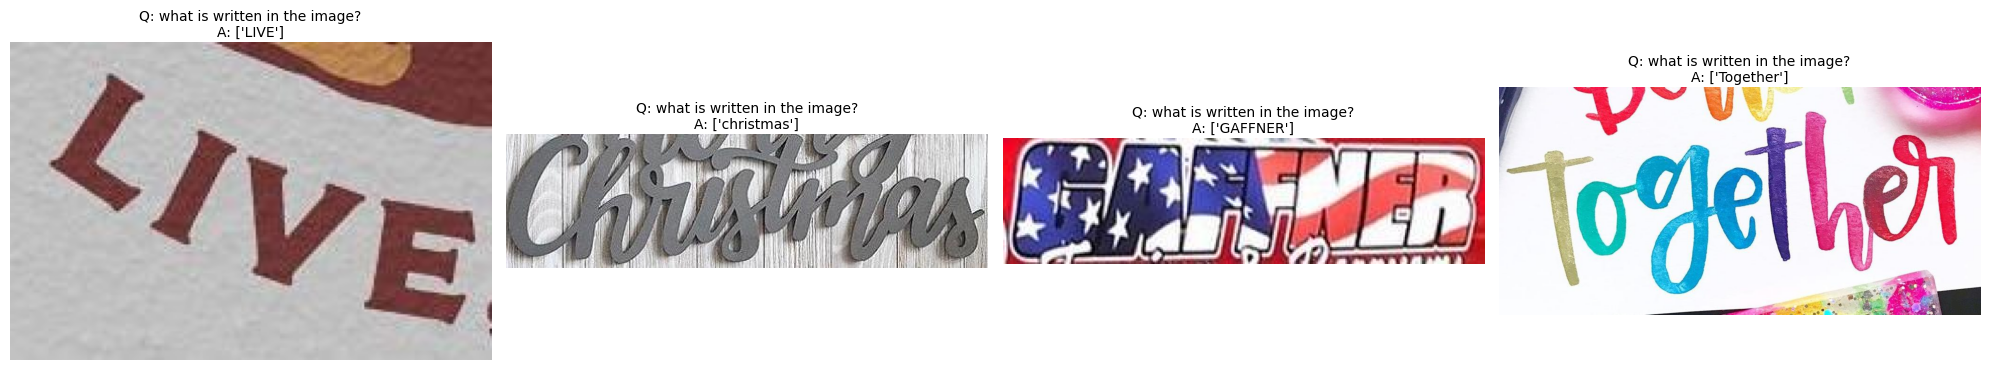

--- Question Type: 'Regular Text Recognition' (4 Samples) ---


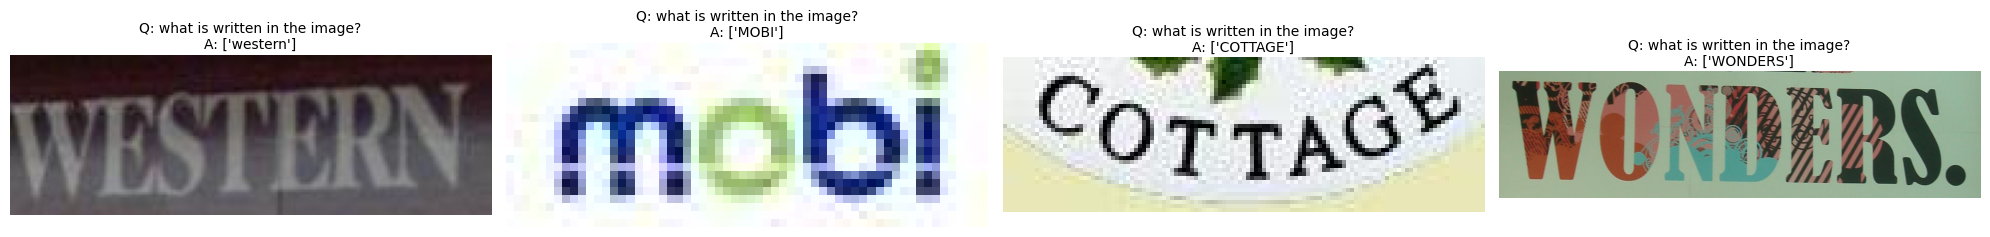

--- Question Type: 'Irregular Text Recognition' (4 Samples) ---


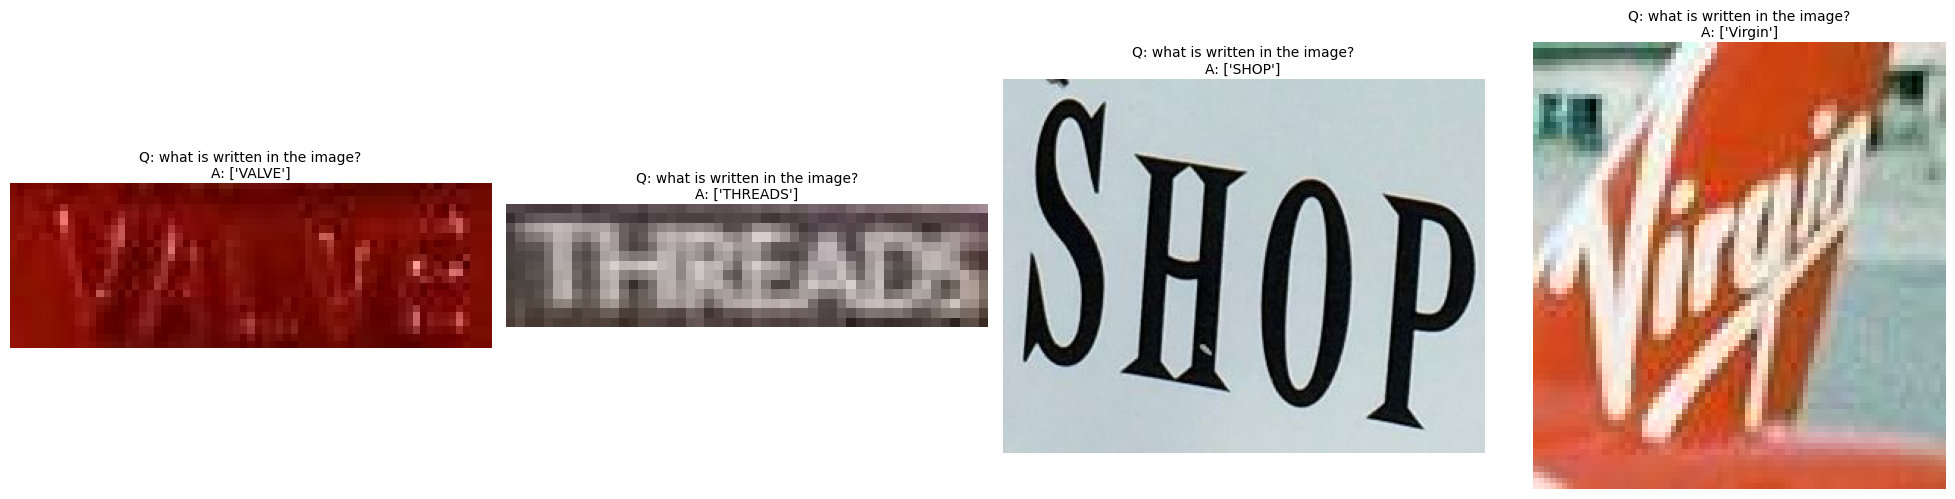

--- Question Type: 'Non-Semantic Text Recognition' (4 Samples) ---


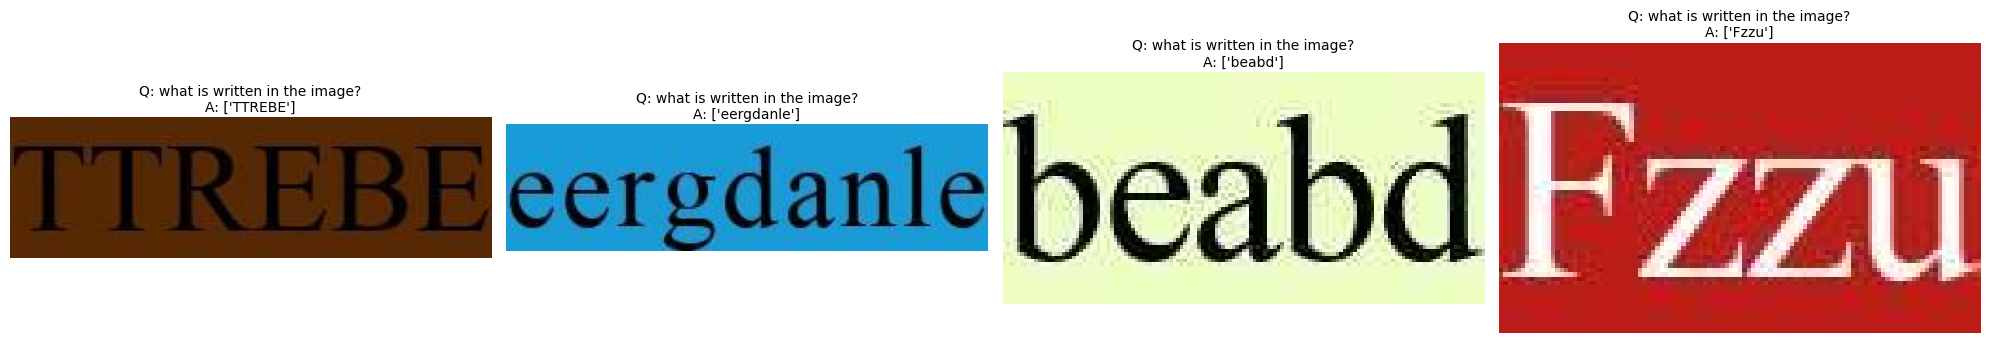

--- Question Type: 'Digit String Recognition' (4 Samples) ---


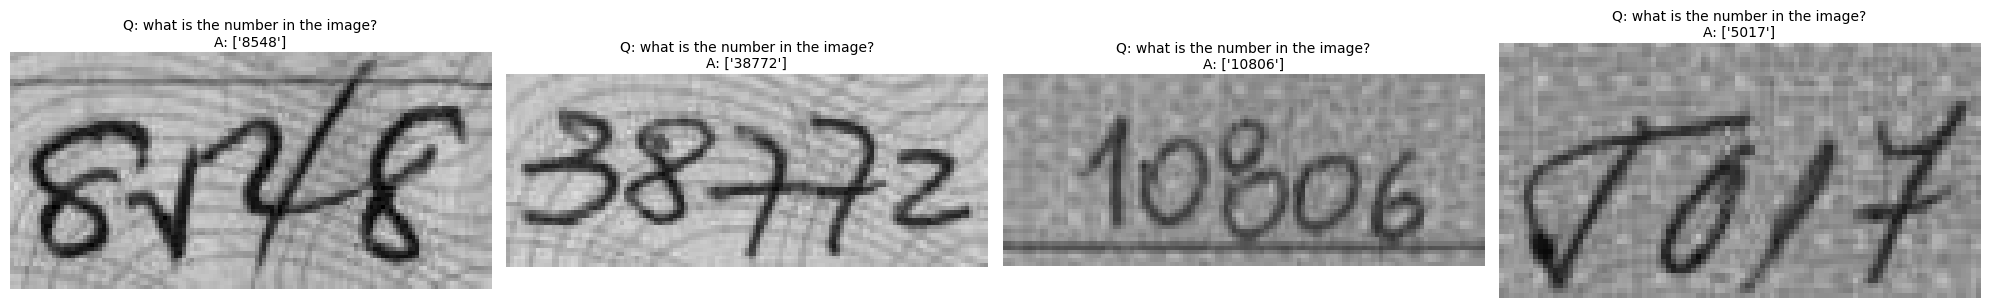

--- Question Type: 'Handwriting Recognition' (4 Samples) ---


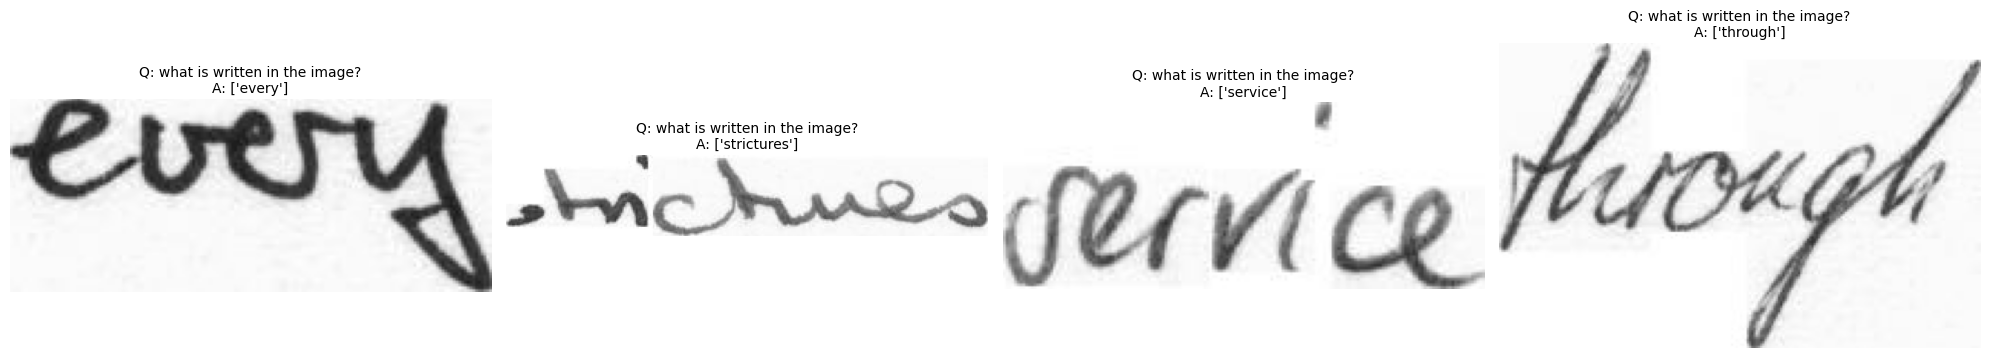

--- Question Type: 'Handwritten Mathematical Expression Recognition' (4 Samples) ---


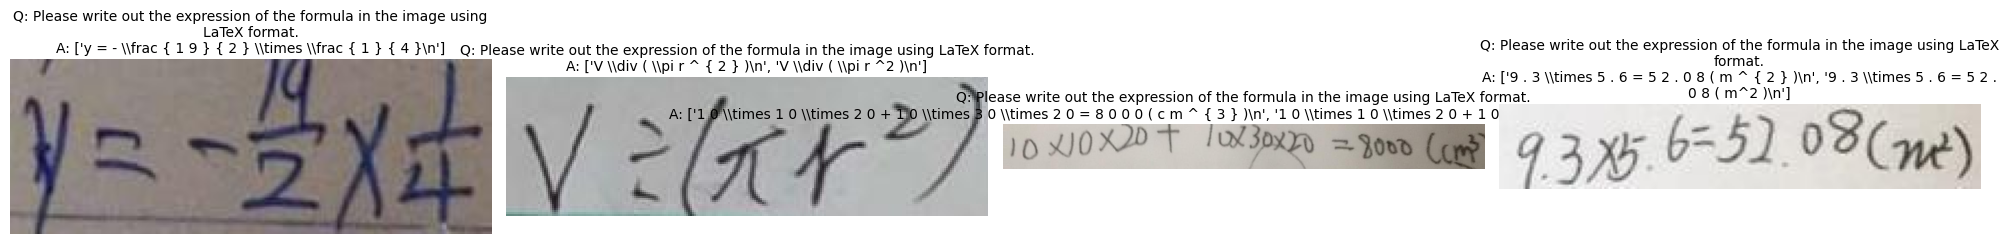

--- Question Type: 'Doc-oriented VQA' (4 Samples) ---


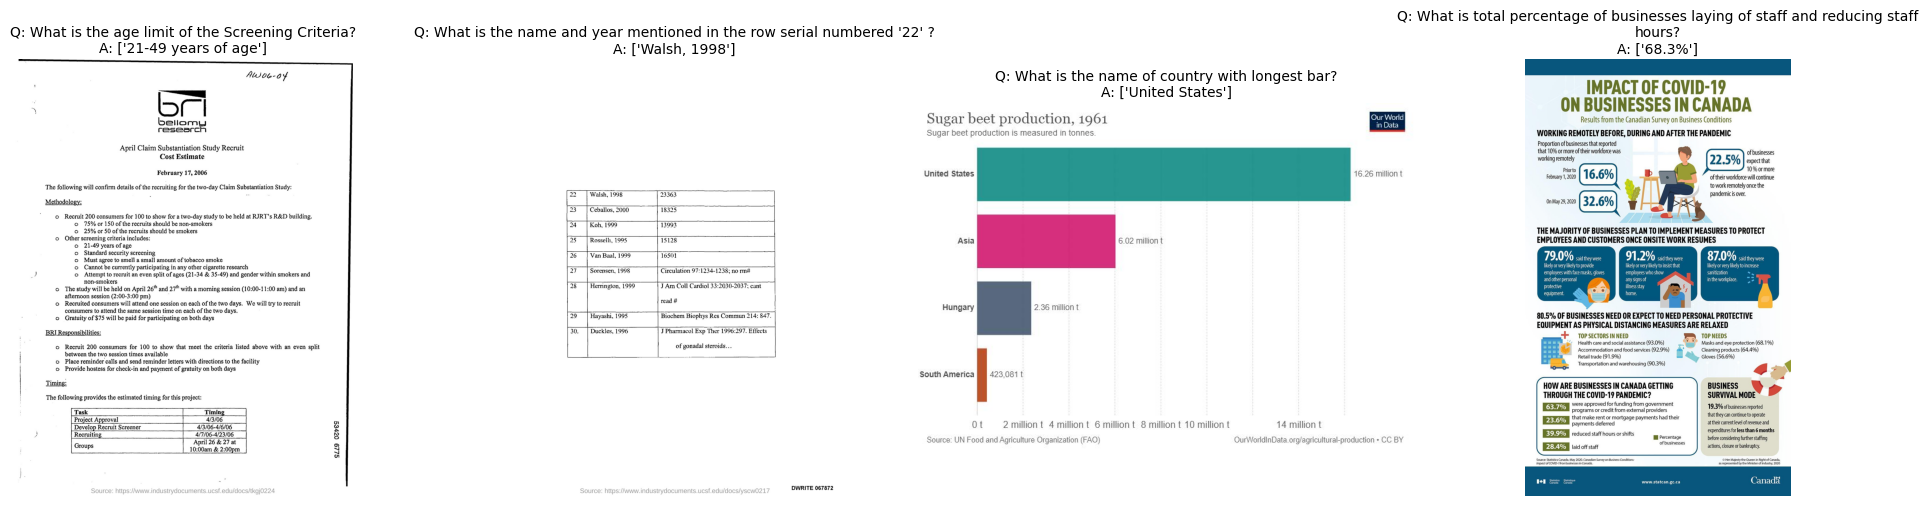

--- Question Type: 'Scene Text-centric VQA' (4 Samples) ---


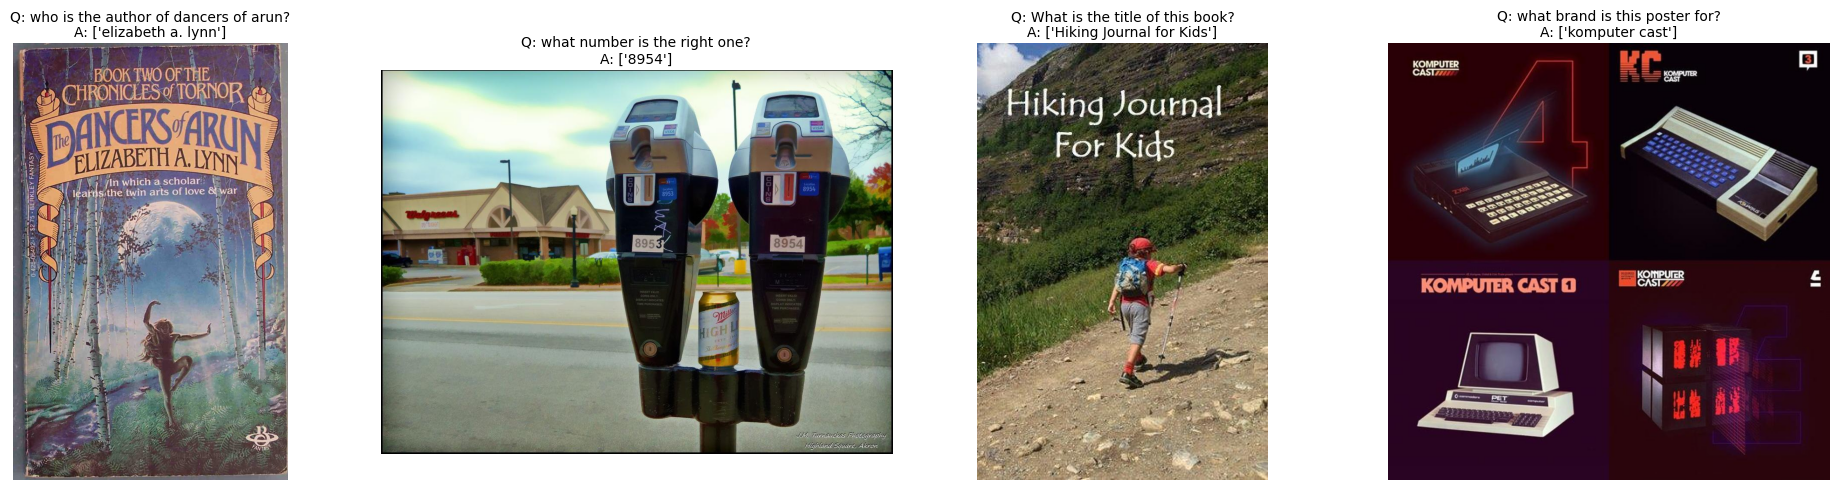

--- Question Type: 'Key Information Extraction' (4 Samples) ---


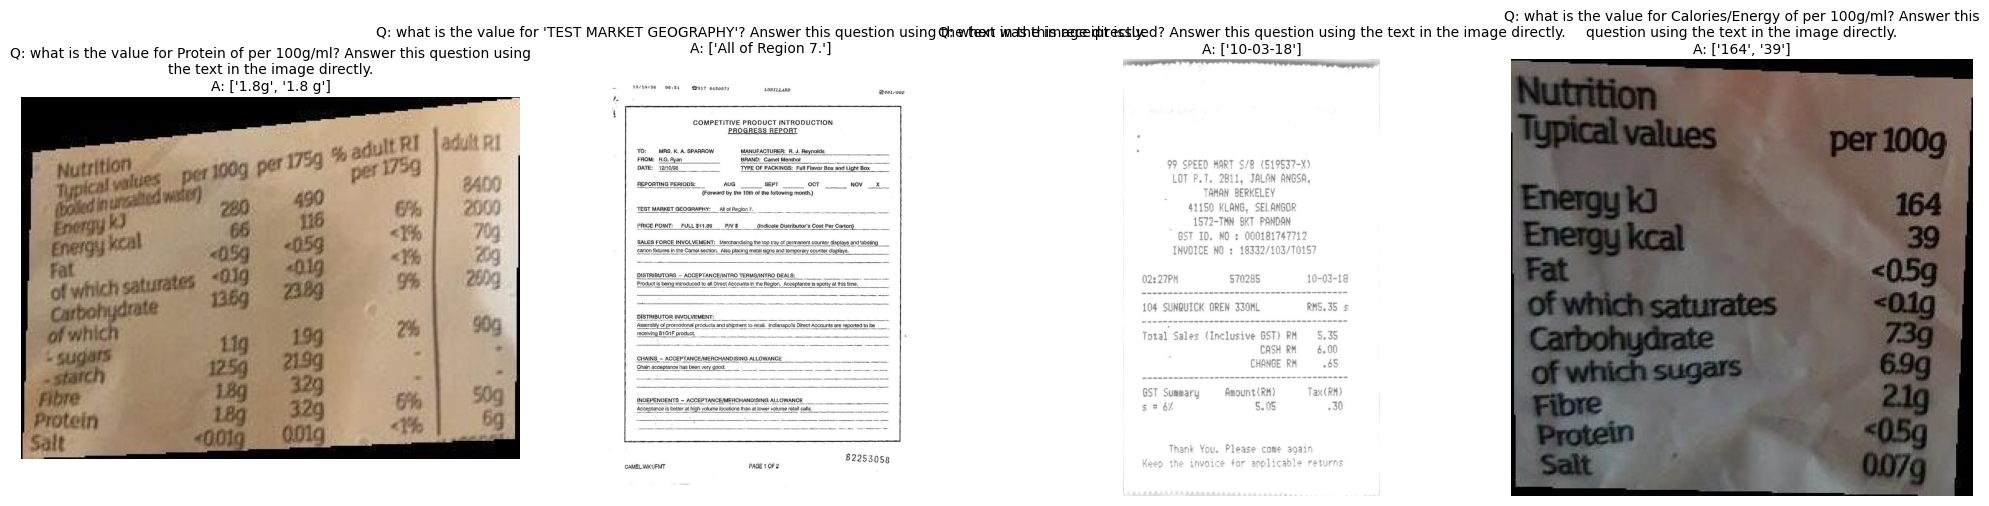

In [18]:
for question_type in question_types:
    visualize_samples(ds, question_type=question_type)